# SIH26174 — Notebook 03: Object Detection Testing (Pretrained YOLOv8)

**Project:** BAS Experiment Monitor (SIH26174) — AI Human Activity Recognition for On-board BAS Experiments
**Part:** Part 1 — Model Development (Training Pipeline)
**Stage:** Notebook 03 of the training pipeline

## 1. Objective and Architecture Boundary

This notebook tests whether **pretrained** Ultralytics YOLOv8 is good enough as the object-detection
supporting component for the SIH26174 internal-round prototype. It is a **diagnostic/testing**
notebook, not a training notebook.

It answers:

1. Does YOLOv8 load correctly?
2. Does pretrained inference run correctly?
3. Which standard (COCO) object classes does it detect in representative HMDB51 frames?
4. What do detection confidence and bounding boxes look like?
5. Are the detections visually reasonable?
6. Is pretrained YOLOv8 practically usable as-is?
7. What are its limitations for this project?

### What this notebook does NOT do

- It does **not** train or fine-tune YOLOv8.
- It does **not** create bounding-box annotations from HMDB51.
- It does **not** fabricate object labels from HMDB51 class names.
- It does **not** run action recognition or train any action-recognition model.
- It does **not** implement experiment validation, state-machine logic, GUI, or voice alerts
  (Part 2 concerns).
- It does **not** run inference over the full HMDB51 dataset — only a small, deterministic sample.

### Architectural boundary (important — two separate label spaces)

```text
Video
  |
  v
YOLOv8 (pretrained, COCO classes)
  |
  v
Object detections   <-- THIS NOTEBOOK

Video
  |
  v
Action Recognition Model (trained on HMDB51, in a later notebook)
  |
  v
Action + confidence

Action + Experiment State
  |
  v
State Machine (Part 2)
  |
  v
VALID / INVALID
```

**HMDB51 action labels** (e.g. `drink`, `catch`, `sword`) and **YOLOv8's pretrained COCO object
labels** (e.g. `person`, `bottle`, `sports ball`) are **different label spaces**. A YOLO detection
in a frame does **not** mean the corresponding HMDB51 action was recognized — those are unrelated
claims. This notebook only reports what objects YOLOv8 sees, nothing about actions.


## 2. Imports

In [1]:
import os
import sys
import json
import time
import random
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

print("Python version:", sys.version.split()[0])
print("OpenCV version:", cv2.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)


Python version: 3.13.15
OpenCV version: 4.14.0
Pandas version: 2.2.3
NumPy version: 2.1.3


### 2.1 Install / Import Ultralytics

Ultralytics is installed if it is not already available. This also brings in PyTorch as a
dependency, which is used below to check for CUDA/GPU availability.


In [2]:
try:
    import ultralytics
    print("Ultralytics already available:", ultralytics.__version__)
except ImportError:
    print("Ultralytics not found — installing (this may take a minute)...")
    %pip install -q ultralytics
    import ultralytics
    print("Ultralytics installed:", ultralytics.__version__)

from ultralytics import YOLO
import torch

print("PyTorch version:", torch.__version__)


Ultralytics not found — installing (this may take a minute)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 6.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics installed: 8.4.135
PyTorch version: 2.11.0+cpu


## 3. Configuration

Every path, model choice, sampling parameter, and threshold used in this notebook is defined here
— nowhere else. `DATASET_ROOT` is the only hardcoded absolute path, consistent with Notebooks 01
and 02.


In [3]:
# ---------------------------------------------------------------------------
# Dataset location (the single hardcoded absolute path allowed in this notebook)
# ---------------------------------------------------------------------------
DATASET_ROOT = Path(
    "/content/drive/MyDrive/Technical-Projects/SIH26174/training/data/raw/hmdb51_sta"
)

# ---------------------------------------------------------------------------
# Project paths, derived from DATASET_ROOT (same convention as Notebooks 01 and 02)
# ---------------------------------------------------------------------------
TRAINING_ROOT = DATASET_ROOT.parents[2]
REPORTS_DIR = TRAINING_ROOT / "reports"

DETECTION_REPORT_JSON_PATH = REPORTS_DIR / "yolov8_detection_test.json"
DETECTION_REPORT_MD_PATH = REPORTS_DIR / "yolov8_detection_test.md"

# Only created if the implementation genuinely needs a project-local weights copy
# (it does not, by default — Ultralytics' own cache is used).
CHECKPOINTS_DIR = TRAINING_ROOT / "checkpoints" / "yolo"

SUPPORTED_VIDEO_EXTENSIONS = {".avi", ".mp4", ".mov", ".mkv", ".webm"}

# ---------------------------------------------------------------------------
# YOLOv8 model configuration
# ---------------------------------------------------------------------------
# yolov8n.pt (nano) is preferred for quick, practical internal-round testing.
# If not cached locally, Ultralytics downloads it automatically — no manual
# download is required.
MODEL_WEIGHTS = "yolov8n.pt"

# ---------------------------------------------------------------------------
# Confidence threshold — defined once, used everywhere below.
# ---------------------------------------------------------------------------
CONFIDENCE_THRESHOLD = 0.25

# ---------------------------------------------------------------------------
# Sampling configuration
# ---------------------------------------------------------------------------
RANDOM_SEED = 42

# Candidate HMDB51 classes that are more likely (not guaranteed) to contain
# COCO-recognizable objects. YOLOv8's detection vocabulary is independent of
# HMDB51's action vocabulary, so some of these may still yield few/no
# detections — that is itself a useful, honest result.
PREFERRED_SAMPLE_CLASSES = [
    "dribble", "golf", "ride_bike", "ride_horse", "shoot_ball",
    "drink", "eat", "catch", "kick_ball", "sword",
]

NUM_CLASSES_TO_SAMPLE = 8       # how many classes to actually test
NUM_VIDEOS_PER_CLASS = 1        # videos sampled per selected class
FRAMES_PER_VIDEO = 2            # representative frames extracted per video

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("DATASET_ROOT           :", DATASET_ROOT)
print("TRAINING_ROOT            :", TRAINING_ROOT)
print("DETECTION_REPORT_JSON_PATH:", DETECTION_REPORT_JSON_PATH)
print("DETECTION_REPORT_MD_PATH :", DETECTION_REPORT_MD_PATH)
print("MODEL_WEIGHTS              :", MODEL_WEIGHTS)
print("CONFIDENCE_THRESHOLD         :", CONFIDENCE_THRESHOLD)
print(f"Sampling up to {NUM_CLASSES_TO_SAMPLE} classes, "
      f"{NUM_VIDEOS_PER_CLASS} video(s)/class, {FRAMES_PER_VIDEO} frame(s)/video")


DATASET_ROOT           : /content/drive/MyDrive/Technical-Projects/SIH26174/training/data/raw/hmdb51_sta
TRAINING_ROOT            : /content/drive/MyDrive/Technical-Projects/SIH26174/training
DETECTION_REPORT_JSON_PATH: /content/drive/MyDrive/Technical-Projects/SIH26174/training/reports/yolov8_detection_test.json
DETECTION_REPORT_MD_PATH : /content/drive/MyDrive/Technical-Projects/SIH26174/training/reports/yolov8_detection_test.md
MODEL_WEIGHTS              : yolov8n.pt
CONFIDENCE_THRESHOLD         : 0.25
Sampling up to 8 classes, 1 video(s)/class, 2 frame(s)/video


## 4. Mount Google Drive

Mounts Drive when running in Colab; falls back gracefully outside Colab as long as `DATASET_ROOT`
is reachable another way.


In [4]:
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
else:
    print(
        "Not running inside Google Colab — skipping drive.mount(). "
        "Make sure DATASET_ROOT is reachable on this filesystem."
    )


Mounted at /content/drive


## 5. Verify Dataset Path

Confirm the HMDB51 dataset root exists before selecting any sample videos. This dataset is treated
strictly as read-only source material — nothing here is renamed, moved, or modified.


In [5]:
if not DATASET_ROOT.exists() or not DATASET_ROOT.is_dir():
    raise FileNotFoundError(
        f"Dataset root does not exist or is not a directory:\n  {DATASET_ROOT}\n"
        "Make sure Google Drive is mounted and the HMDB51 dataset has been extracted here."
    )

print("Dataset root OK:", DATASET_ROOT)


Dataset root OK: /content/drive/MyDrive/Technical-Projects/SIH26174/training/data/raw/hmdb51_sta


## 6. Load Pretrained YOLOv8

Load the pretrained model, print its name, and confirm it loaded successfully. No training or
fine-tuning happens here or anywhere else in this notebook.


In [6]:
model_load_start = time.time()
model = YOLO(MODEL_WEIGHTS)
model_load_seconds = time.time() - model_load_start

print(f"Loaded model weights : {MODEL_WEIGHTS}")
print(f"Model task            : {model.task}")
print(f"Number of classes     : {len(model.names)}")
print(f"Model load time        : {model_load_seconds:.2f}s")
print("Model loaded successfully.")


Loaded model weights : yolov8n.pt
Model task            : detect
Number of classes     : 80
Model load time        : 0.67s
Model loaded successfully.


## 7. Verify Inference Device

Use CUDA if available, otherwise CPU. The notebook must not fail merely because a GPU is
unavailable — Colab CPU-only runtimes are a valid (if slower) environment for this test.


In [7]:
cuda_available = torch.cuda.is_available()
DEVICE = "cuda" if cuda_available else "cpu"

print("CUDA available:", cuda_available)
print("Device used   :", DEVICE)
if cuda_available:
    print("GPU name       :", torch.cuda.get_device_name(0))


CUDA available: False
Device used   : cpu


## 8. Select Representative HMDB51 Videos

Deterministically select a small set of HMDB51 videos to test against. We start from
`PREFERRED_SAMPLE_CLASSES` — action classes more likely to contain COCO-recognizable objects — but
only keep the ones that actually exist in this dataset copy, and top up with other randomly chosen
(but seeded) classes if needed to reach `NUM_CLASSES_TO_SAMPLE`.

This selection is for **testing convenience only**. It does not imply that HMDB51 class names are
YOLO object classes, and it does not guarantee every selected class will contain a detectable
object.


In [8]:
def discover_class_dirs(dataset_root: Path):
    return sorted(p.name for p in dataset_root.iterdir() if p.is_dir() and not p.name.startswith("."))


def find_video_files(class_dir: Path):
    if not class_dir.is_dir():
        return []
    return sorted(
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in SUPPORTED_VIDEO_EXTENSIONS
    )


all_class_names = discover_class_dirs(DATASET_ROOT)
print(f"Total HMDB51 classes found on disk: {len(all_class_names)}")

available_preferred = [c for c in PREFERRED_SAMPLE_CLASSES if c in all_class_names]
missing_preferred = [c for c in PREFERRED_SAMPLE_CLASSES if c not in all_class_names]

if missing_preferred:
    print(f"NOTE: {len(missing_preferred)} preferred class(es) not present in this dataset copy "
          f"and will be skipped: {missing_preferred}")

rng = random.Random(RANDOM_SEED)

selected_classes = available_preferred[:NUM_CLASSES_TO_SAMPLE]
if len(selected_classes) < NUM_CLASSES_TO_SAMPLE:
    remaining_pool = [c for c in all_class_names if c not in selected_classes]
    rng.shuffle(remaining_pool)
    needed = NUM_CLASSES_TO_SAMPLE - len(selected_classes)
    selected_classes.extend(remaining_pool[:needed])

selected_classes = sorted(selected_classes)
print(f"Selected {len(selected_classes)} classes for this test:")
print(" ", selected_classes)


Total HMDB51 classes found on disk: 51
Selected 8 classes for this test:
  ['catch', 'dribble', 'drink', 'eat', 'golf', 'ride_bike', 'ride_horse', 'shoot_ball']


In [9]:
sample_video_records = []  # {video_path: Path, class_name: str}

for class_name in selected_classes:
    class_dir = DATASET_ROOT / class_name
    videos = find_video_files(class_dir)
    if not videos:
        print(f"WARNING: no video files found for class '{class_name}' — skipping.")
        continue

    chosen = rng.sample(videos, min(NUM_VIDEOS_PER_CLASS, len(videos)))
    for video_path in chosen:
        sample_video_records.append({"video_path": video_path, "class_name": class_name})

print(f"Total sample videos selected: {len(sample_video_records)}")
for rec in sample_video_records:
    print(f"  [{rec['class_name']}] {rec['video_path'].name}")


Total sample videos selected: 8
  [catch] Torwarttraining_catch_f_cm_np1_le_bad_11.avi
  [dribble] Basketball_Dribbling_-_Basketball_Dribbling-_Finger_Pads_dribble_f_cm_np1_fr_med_0.avi
  [drink] AMADEUS_drink_u_nm_np1_fr_goo_11.avi
  [eat] The_Departed_-_Part_1_eat_u_nm_np1_fr_goo_1.avi
  [golf] Golf_Swing_#6Iron_golf_f_cm_np1_ri_med_5.avi
  [ride_bike] Fahrrad_fahren_mit_Albert_ride_bike_f_cm_np1_ba_med_1.avi
  [ride_horse] Caspar_ride_horse_f_cm_np1_ri_med_2.avi
  [shoot_ball] BrandonWebmanplayingbasketball_shoot_ball_f_nm_np1_le_med_0.avi


## 9. Extract Representative Frames

For each selected video, extract a small number of evenly spaced frames (`FRAMES_PER_VIDEO`)
rather than scanning the whole video. Unreadable videos are reported and skipped, not treated as a
fatal error.


In [10]:
def extract_representative_frames(video_path: Path, num_frames: int):
    """Return up to num_frames evenly spaced BGR frames from a video, or [] on failure."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        cap.release()
        return []

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if frame_count <= 0:
        cap.release()
        return []

    if num_frames == 1:
        indices = [frame_count // 2]
    else:
        indices = np.linspace(0, frame_count - 1, num=num_frames)
        indices = sorted(set(np.round(indices).astype(int).tolist()))

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ok, frame = cap.read()
        if ok and frame is not None:
            frames.append({"frame_index": int(idx), "frame": frame})

    cap.release()
    return frames


test_frames = []  # {video_path, class_name, frame_index, frame (BGR np.ndarray)}
unreadable_sample_videos = []

for rec in sample_video_records:
    frames = extract_representative_frames(rec["video_path"], FRAMES_PER_VIDEO)
    if not frames:
        unreadable_sample_videos.append(str(rec["video_path"]))
        continue
    for item in frames:
        test_frames.append({
            "video_path": rec["video_path"],
            "class_name": rec["class_name"],
            "frame_index": item["frame_index"],
            "frame": item["frame"],
        })

print(f"Representative frames extracted: {len(test_frames)}")
if unreadable_sample_videos:
    print(f"WARNING: {len(unreadable_sample_videos)} sample video(s) could not be read:")
    for v in unreadable_sample_videos:
        print("  -", v)


Representative frames extracted: 8


## 10. Run YOLOv8 Inference

Run pretrained YOLOv8 inference on each extracted frame. For every detection above
`CONFIDENCE_THRESHOLD` we record the source video, the HMDB51 action-class label, the detected
YOLO object class, its confidence, and its bounding box — explicitly keeping these two label
spaces (action vs. object) as separate columns.


In [11]:
detection_records = []
per_frame_results = []  # keeps the raw Results object per frame, for visualization later
per_frame_timings = []

for item in test_frames:
    frame_bgr = item["frame"]

    start = time.time()
    results = model.predict(source=frame_bgr, conf=CONFIDENCE_THRESHOLD, device=DEVICE, verbose=False)
    elapsed = time.time() - start
    per_frame_timings.append(elapsed)

    result = results[0]
    per_frame_results.append({
        "video_path": item["video_path"],
        "class_name": item["class_name"],
        "frame_index": item["frame_index"],
        "result": result,
    })

    boxes = result.boxes
    if boxes is not None and len(boxes) > 0:
        for box in boxes:
            cls_id = int(box.cls[0])
            confidence = float(box.conf[0])
            x1, y1, x2, y2 = [float(v) for v in box.xyxy[0].tolist()]

            detection_records.append({
                "source_video": str(item["video_path"]),
                "hmdb51_action_class": item["class_name"],
                "frame_index": item["frame_index"],
                "yolo_object_class": model.names[cls_id],
                "confidence": round(confidence, 4),
                "bbox_xyxy": [round(x1, 1), round(y1, 1), round(x2, 1), round(y2, 1)],
            })

detections_df = pd.DataFrame(detection_records)

print(f"Frames tested        : {len(test_frames)}")
print(f"Total detections     : {len(detections_df)}")
frames_with_detection = len({(d['source_video'], d['frame_index']) for d in detection_records})
print(f"Frames with >=1 detection: {frames_with_detection} / {len(test_frames)}")
detections_df.head(10)


Frames tested        : 8
Total detections     : 32
Frames with >=1 detection: 8 / 8


,source_video,hmdb51_action_class,frame_index,yolo_object_class,confidence,bbox_xyxy
0,/content/drive/MyDrive/Technical-Projects/SIH2...,catch,0,person,0.8767,"[146.0, 81.0, 167.7, 139.5]"
1,/content/drive/MyDrive/Technical-Projects/SIH2...,catch,0,person,0.8551,"[103.5, 80.1, 123.5, 141.2]"
2,/content/drive/MyDrive/Technical-Projects/SIH2...,catch,0,person,0.8501,"[247.6, 74.6, 271.6, 146.4]"
3,/content/drive/MyDrive/Technical-Projects/SIH2...,catch,0,person,0.8023,"[27.5, 74.7, 52.6, 134.4]"
4,/content/drive/MyDrive/Technical-Projects/SIH2...,catch,0,person,0.7693,"[2.0, 70.2, 32.9, 143.9]"
5,/content/drive/MyDrive/Technical-Projects/SIH2...,catch,0,sports ball,0.5762,"[128.3, 133.3, 136.2, 141.8]"
6,/content/drive/MyDrive/Technical-Projects/SIH2...,dribble,0,person,0.8926,"[152.5, 54.4, 198.6, 169.2]"
7,/content/drive/MyDrive/Technical-Projects/SIH2...,dribble,0,person,0.8715,"[51.0, 60.6, 95.6, 174.2]"
8,/content/drive/MyDrive/Technical-Projects/SIH2...,dribble,0,person,0.8501,"[249.1, 61.0, 281.6, 148.0]"
9,/content/drive/MyDrive/Technical-Projects/SIH2...,dribble,0,handbag,0.3458,"[61.4, 106.1, 86.8, 139.7]"


## 11. Visualize Detections

Show annotated frames (bounding boxes + YOLO class + confidence) for a small subset of the tested
frames, so the detections can be judged visually. Each figure caption also shows the HMDB51 action
label for context — this is display convenience only, not a claim that the two labels are related.


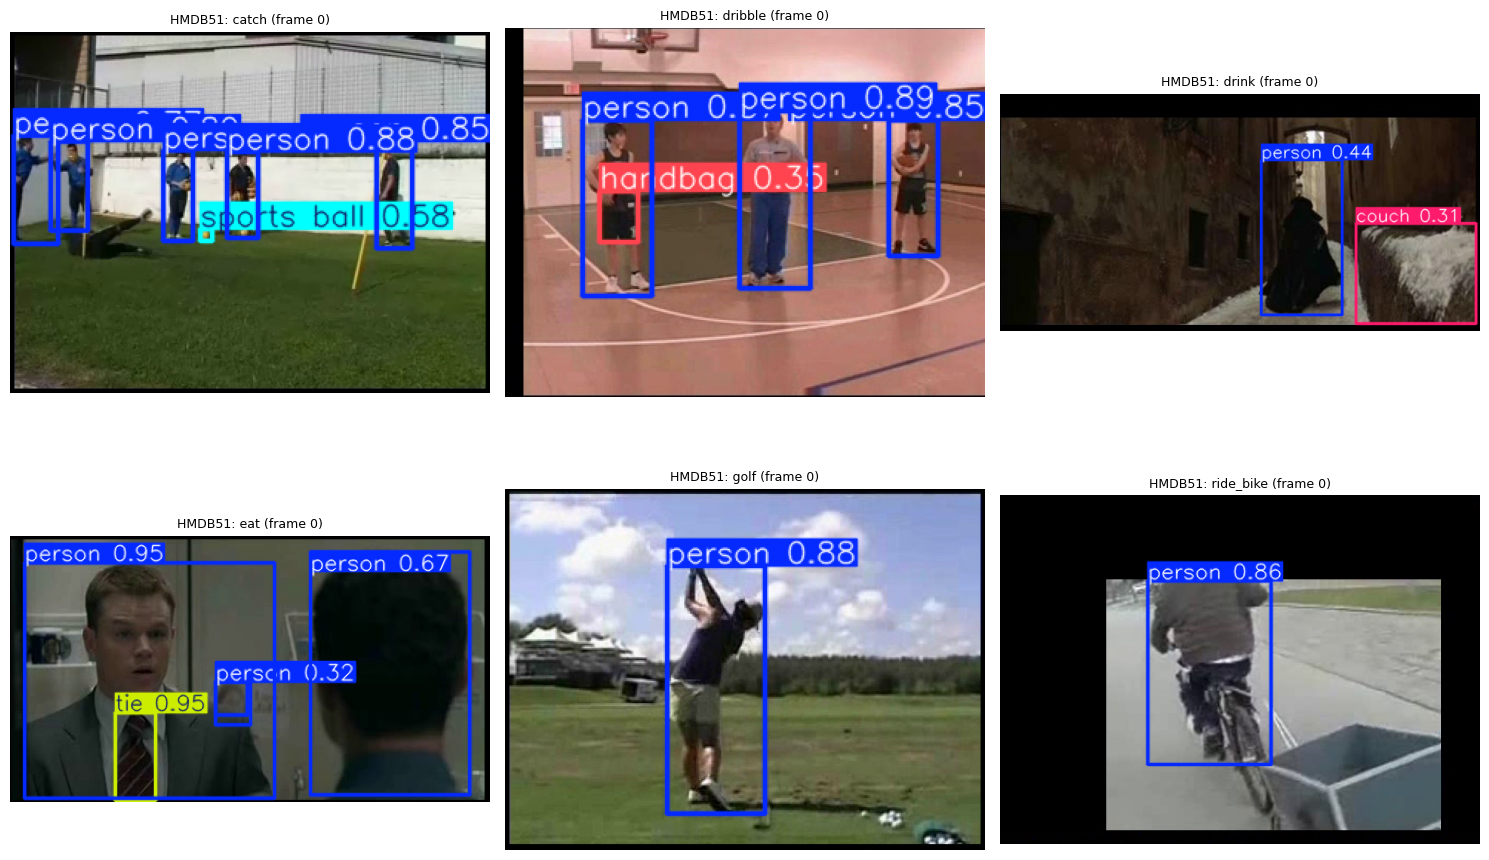

In [12]:
MAX_VISUALIZED_FRAMES = 6

frames_to_show = per_frame_results[:MAX_VISUALIZED_FRAMES]
num_show = len(frames_to_show)

if num_show == 0:
    print("No frames available to visualize.")
else:
    cols = min(3, num_show)
    rows = (num_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, item in zip(axes, frames_to_show):
        annotated_bgr = item["result"].plot()  # ultralytics draws boxes/labels/confidence
        annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
        ax.imshow(annotated_rgb)
        ax.set_title(f"HMDB51: {item['class_name']} (frame {item['frame_index']})", fontsize=9)
        ax.axis("off")

    for ax in axes[num_show:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


## 12. Summarize Detected Objects

Aggregate which YOLO object classes appeared in the sample, and how often, across all tested
frames.


In [13]:
if not detections_df.empty:
    object_class_counts = (
        detections_df["yolo_object_class"].value_counts().rename_axis("yolo_object_class")
        .reset_index(name="detection_count")
    )
    detected_object_classes = sorted(detections_df["yolo_object_class"].unique().tolist())
else:
    object_class_counts = pd.DataFrame(columns=["yolo_object_class", "detection_count"])
    detected_object_classes = []

print(f"Distinct YOLO object classes detected: {len(detected_object_classes)}")
print(detected_object_classes)
object_class_counts


Distinct YOLO object classes detected: 8
['backpack', 'car', 'couch', 'handbag', 'horse', 'person', 'sports ball', 'tie']


,yolo_object_class,detection_count
0,person,24
1,car,2
2,handbag,1
3,sports ball,1
4,couch,1
5,tie,1
6,horse,1
7,backpack,1


## 13. Lightweight Inference Performance

A small, indicative timing measurement over the tested frames only — this is not a formal
benchmark.


In [14]:
num_frames_tested = len(per_frame_timings)
total_inference_seconds = float(sum(per_frame_timings))
avg_inference_seconds = (total_inference_seconds / num_frames_tested) if num_frames_tested else 0.0
approx_fps = (1.0 / avg_inference_seconds) if avg_inference_seconds > 0 else 0.0

print(f"Frames tested            : {num_frames_tested}")
print(f"Total inference time     : {total_inference_seconds:.3f}s")
print(f"Average inference time    : {avg_inference_seconds * 1000:.1f} ms/frame")
print(f"Approximate FPS           : {approx_fps:.1f}")
print("(Note: first-call timing can include lazy CUDA/graph warm-up; treat this as indicative only.)")


Frames tested            : 8
Total inference time     : 8.408s
Average inference time    : 1051.0 ms/frame
Approximate FPS           : 1.0
(Note: first-call timing can include lazy CUDA/graph warm-up; treat this as indicative only.)


## 14. Analyze Limitations

An honest, observation-based assessment. Nothing here is fabricated — it is derived only from the
detections actually produced above.


In [15]:
classes_with_no_detection = sorted({
    item["class_name"] for item in test_frames
} - {rec["hmdb51_action_class"] for rec in detection_records})

detection_rate = (frames_with_detection / len(test_frames)) if test_frames else 0.0

limitation_notes = []
limitation_notes.append(
    f"Pretrained YOLOv8 ({MODEL_WEIGHTS}) detects only its {len(model.names)} pretrained "
    "(COCO) object classes. It has no awareness of HMDB51 action labels or any future "
    "SIH laboratory-experiment object names."
)
limitation_notes.append(
    f"Across the {len(test_frames)} tested frames, {frames_with_detection} frame(s) "
    f"({detection_rate:.0%}) produced at least one detection above the confidence threshold "
    f"({CONFIDENCE_THRESHOLD})."
)
if classes_with_no_detection:
    limitation_notes.append(
        "The following sampled HMDB51 classes produced zero detections in their tested "
        f"frame(s), meaning none of the pretrained COCO classes matched the frame content "
        f"at the current threshold: {classes_with_no_detection}."
    )
if detected_object_classes:
    limitation_notes.append(
        f"Detected object classes were limited to: {detected_object_classes}. Laboratory-specific "
        "items relevant to the eventual SIH experiment (e.g. beakers, sample containers, "
        "instrument panels, payload-rack hardware) are not part of the standard COCO vocabulary "
        "and would not be expected to appear here."
    )
else:
    limitation_notes.append(
        "No objects were detected in any sampled frame at the current confidence threshold. "
        "This could reflect a genuinely low-object-content sample, an unsuitable class "
        "selection, or a threshold that is too strict — the visualizations above should be "
        "reviewed manually before drawing conclusions."
    )
limitation_notes.append(
    "This test used a small, deterministic sample (not the full dataset) and did not include "
    "any laboratory-specific experiment footage, since none exists yet. It cannot determine "
    "detection performance on the eventual custom experiment objects."
)

print("Observed limitations:")
for note in limitation_notes:
    print(" -", note)


Observed limitations:
 - Pretrained YOLOv8 (yolov8n.pt) detects only its 80 pretrained (COCO) object classes. It has no awareness of HMDB51 action labels or any future SIH laboratory-experiment object names.
 - Across the 8 tested frames, 8 frame(s) (100%) produced at least one detection above the confidence threshold (0.25).
 - Detected object classes were limited to: ['backpack', 'car', 'couch', 'handbag', 'horse', 'person', 'sports ball', 'tie']. Laboratory-specific items relevant to the eventual SIH experiment (e.g. beakers, sample containers, instrument panels, payload-rack hardware) are not part of the standard COCO vocabulary and would not be expected to appear here.
 - This test used a small, deterministic sample (not the full dataset) and did not include any laboratory-specific experiment footage, since none exists yet. It cannot determine detection performance on the eventual custom experiment objects.


## 15. Save Test Report

Save a machine-readable report to `training/reports/yolov8_detection_test.json`, and a
human-readable version to `training/reports/yolov8_detection_test.md`.


In [16]:
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# NOTE: This notebook deliberately does NOT compute an automatic
# sufficient/insufficient decision for pretrained YOLOv8. HMDB51 is an
# action-recognition dataset, not the final SIH laboratory object-detection
# dataset, and this test covers only a small representative sample of frames.
# Therefore fine-tuning sufficiency cannot be scientifically determined here —
# the notebook reports observations only, not a model-selection decision.
BASELINE_STATUS = "PRETRAINED YOLOv8 BASELINE TEST COMPLETE"
FINE_TUNING_DECISION = "NOT DETERMINED"
FINE_TUNING_DECISION_REASON = (
    "Baseline test complete. Sufficiency for the final SIH laboratory experiment "
    "cannot yet be determined because HMDB51 is not the laboratory object-detection "
    "dataset and this notebook evaluates only a small representative sample."
)

report = {
    "notebook": "training/notebooks/03_object_detection_testing.ipynb",
    "model": {
        "weights": MODEL_WEIGHTS,
        "task": model.task,
        "num_pretrained_classes": len(model.names),
    },
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "device": DEVICE,
    "cuda_available": cuda_available,
    "sampling": {
        "random_seed": RANDOM_SEED,
        "selected_classes": selected_classes,
        "num_sample_videos": len(sample_video_records),
        "frames_per_video": FRAMES_PER_VIDEO,
        "num_frames_tested": num_frames_tested,
        "unreadable_sample_videos": unreadable_sample_videos,
    },
    "timing": {
        "total_inference_seconds": round(total_inference_seconds, 4),
        "avg_inference_seconds_per_frame": round(avg_inference_seconds, 4),
        "approx_fps": round(approx_fps, 2),
    },
    "results": {
        "total_detections": len(detection_records),
        "frames_with_detection": frames_with_detection,
        "detection_rate": round(detection_rate, 4),
        "detected_object_classes": detected_object_classes,
        "object_class_counts": object_class_counts.to_dict(orient="records"),
        "detections": detection_records,
    },
    "limitations": limitation_notes,
    "baseline_status": BASELINE_STATUS,
    "fine_tuning_decision": FINE_TUNING_DECISION,
    "fine_tuning_decision_reason": FINE_TUNING_DECISION_REASON,
}

with open(DETECTION_REPORT_JSON_PATH, "w") as f:
    json.dump(report, f, indent=2)

print("Saved JSON report ->", DETECTION_REPORT_JSON_PATH)


Saved JSON report -> /content/drive/MyDrive/Technical-Projects/SIH26174/training/reports/yolov8_detection_test.json


In [17]:
md_lines = []
md_lines.append("# YOLOv8 Pretrained Object Detection Test\n\n")
md_lines.append(f"- **Model weights:** `{MODEL_WEIGHTS}`\n")
md_lines.append(f"- **Device:** {DEVICE} (CUDA available: {cuda_available})\n")
md_lines.append(f"- **Confidence threshold:** {CONFIDENCE_THRESHOLD}\n")
md_lines.append(f"- **Frames tested:** {num_frames_tested}\n")
md_lines.append(f"- **Total detections:** {len(detection_records)}\n")
md_lines.append(f"- **Frames with >=1 detection:** {frames_with_detection}/{num_frames_tested} "
                 f"({detection_rate:.0%})\n")
md_lines.append(f"- **Detected object classes:** {detected_object_classes}\n")
md_lines.append(f"- **Approx. FPS:** {approx_fps:.1f}\n\n")

md_lines.append("## Limitations\n\n")
for note in limitation_notes:
    md_lines.append(f"- {note}\n")

md_lines.append("\n## Baseline Status\n\n")
md_lines.append(f"**{BASELINE_STATUS}**\n\n")
md_lines.append("## Fine-Tuning Decision\n\n")
md_lines.append(f"**{FINE_TUNING_DECISION}**\n\n")
md_lines.append(f"{FINE_TUNING_DECISION_REASON}\n")

with open(DETECTION_REPORT_MD_PATH, "w") as f:
    f.writelines(md_lines)

print("Saved Markdown report ->", DETECTION_REPORT_MD_PATH)


Saved Markdown report -> /content/drive/MyDrive/Technical-Projects/SIH26174/training/reports/yolov8_detection_test.md


## 16. Final Recommendation

Consolidated output. This notebook reports observations about pretrained YOLOv8's behavior on a
small HMDB51 sample — it does **not** make an automatic sufficient/insufficient decision, and it
does not automatically start any fine-tuning pipeline. HMDB51 is not the final SIH laboratory
object-detection dataset, so sufficiency for that eventual task cannot be determined here.


In [18]:
print("=" * 70)
print("NOTEBOOK 03 — OBJECT DETECTION TESTING — FINAL SUMMARY")
print("=" * 70)
print(f"YOLO model             : {MODEL_WEIGHTS}")
print(f"Weight                  : {MODEL_WEIGHTS}")
print(f"Device                   : {DEVICE}")
print(f"Confidence threshold      : {CONFIDENCE_THRESHOLD}")
print(f"Frames tested               : {num_frames_tested}")
print(f"Average inference time        : {avg_inference_seconds * 1000:.1f} ms/frame")
print(f"Approximate FPS                : {approx_fps:.1f}")
print(f"Object classes detected         : {detected_object_classes}")
print(f"Baseline status                   : {BASELINE_STATUS}")
print(f"Fine-tuning decision               : {FINE_TUNING_DECISION}")
print(f"Reason                               : {FINE_TUNING_DECISION_REASON}")
print("=" * 70)
print("Reminder: pretrained YOLOv8 was NOT trained or fine-tuned in this notebook.")
print("No action-recognition model was trained or modified in this notebook.")
print("Generated files:")
print(f"  - {DETECTION_REPORT_JSON_PATH}")
print(f"  - {DETECTION_REPORT_MD_PATH}")


NOTEBOOK 03 — OBJECT DETECTION TESTING — FINAL SUMMARY
YOLO model             : yolov8n.pt
Weight                  : yolov8n.pt
Device                   : cpu
Confidence threshold      : 0.25
Frames tested               : 8
Average inference time        : 1051.0 ms/frame
Approximate FPS                : 1.0
Object classes detected         : ['backpack', 'car', 'couch', 'handbag', 'horse', 'person', 'sports ball', 'tie']
Baseline status                   : PRETRAINED YOLOv8 BASELINE TEST COMPLETE
Fine-tuning decision               : NOT DETERMINED
Reason                               : Baseline test complete. Sufficiency for the final SIH laboratory experiment cannot yet be determined because HMDB51 is not the laboratory object-detection dataset and this notebook evaluates only a small representative sample.
Reminder: pretrained YOLOv8 was NOT trained or fine-tuned in this notebook.
No action-recognition model was trained or modified in this notebook.
Generated files:
  - /content/drive